# Statistical Analysis — Synthetic Gender Sensitization Survey
## ⚠️ SYNTHETIC DATA DISCLAIMER

**This entire notebook operates on `synthetic_survey.csv`, a 100% artificially
generated dataset.**

- No real survey respondents are represented in this file.
- The data was produced by a Python script (`generate_dataset.py`) using
  random sampling, loosely targeting the *aggregate* percentages published
  in a dissertation on gender sensitization in Kanpur — but **no real
  individual-level responses were ever used**.
- Some relationships between variables (e.g., education vs. awareness) were
  **deliberately and artificially injected** into the data generation process
  purely to make the dataset useful for analytics/ML demonstrations.
- **Do not** interpret any statistic, chart, or "finding" in this notebook as
  evidence about real attitudes, real people, or the real world. This is a
  technical demonstration only.


## 1. Import Libraries
We use `pandas`/`numpy` for data handling, `matplotlib`/`plotly` for visualization, and `scipy.stats` for statistical tests (chi-square test of independence, used here for demonstration purposes on categorical survey data).

In [1]:
# Core data-handling libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Statistical testing
from scipy.stats import chi2_contingency

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

pd.set_option('display.max_columns', None)
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Cleaned Synthetic Dataset

In [2]:
# Load the cleaned dataset if available, otherwise fall back to raw file
import os

if os.path.exists("synthetic_survey_cleaned.csv"):
    df = pd.read_csv("synthetic_survey_cleaned.csv")
    print("Loaded 'synthetic_survey_cleaned.csv'.")
else:
    df = pd.read_csv("synthetic_survey.csv")
    print("Cleaned file not found — loaded raw 'synthetic_survey.csv' instead.")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nReminder: this is a SYNTHETIC dataset. All statistics below describe")
print("artificially generated data only — not real-world populations.")

df.head()


Loaded 'synthetic_survey_cleaned.csv'.
Dataset shape: 1000 rows x 28 columns

Reminder: this is a SYNTHETIC dataset. All statistics below describe
artificially generated data only — not real-world populations.


,respondent_id,age_group,gender,education,heard_term_gender_sensitization,gender_is_binary_or_nonbinary,received_gender_training,support_school_curriculum,support_workplace_training,sensitization_helps_relationships,stereotype_men_rational_women_emotional,stereotype_women_bad_drivers,view_okay_for_men_to_cry,stereotype_men_strong_women_weak,stereotype_women_better_housekeepers,stereotype_gentle_men_less_masculine,childcare_only_mother_responsibility,woman_home_man_provider_role,chores_divided_equally_if_both_work,support_equal_pay,support_gender_diversity_quotas,discrimination_observed_nearby,support_gender_neutral_language,encourage_girls_nontraditional_careers,man_should_have_final_say_home,woman_should_not_tolerate_violence,sexist_jokes_okay,sensitization_reduces_gbv
0,R0001,18-25,Female,Bachelor's degree,Yes,Non-binary,No,Maybe,"Yes, definitely",Yes,Agree,Disagree,Agree,Agree,Agree,Disagree,No,Yes,"Yes, definitely",Yes,Yes,No,Maybe,Yes,No,Maybe,No,Yes
1,R0002,18-25,Male,Bachelor's degree,No,Non-binary,No,"No, not required","Yes, definitely",Yes,Disagree,Disagree,Agree,Disagree,Disagree,Agree,Yes,Yes,"Yes, definitely",Yes,Yes,Yes,Yes,Yes,No,No,No,Maybe
2,R0003,18-25,Female,Bachelor's degree,Yes,Binary,Yes,"No, not required","Yes, definitely",Yes,Disagree,Neutral,Agree,Disagree,Agree,Disagree,No,Yes,"No, the woman should manage both",Yes,Yes,No,Yes,Maybe,No,No,No,Yes
3,R0004,18-25,Male,Master's degree,Yes,Binary,No,"Yes, definitely","Yes, definitely",Yes,Agree,Disagree,Agree,Disagree,Agree,Disagree,No,No,"No, the woman should manage both",Yes,Yes,No,Yes,Yes,No,No,No,Yes
4,R0005,26-35,Male,Master's degree,Yes,Non-binary,Yes,Maybe,Maybe,Yes,Disagree,Disagree,Agree,Disagree,Disagree,Disagree,No,Yes,"Yes, definitely",Yes,Unsure,Unsure,Maybe,Yes,No,Yes,Maybe,Yes


## 3. Re-apply Ordinal Ordering

In [3]:
# Re-establish logical category order for age and education (lost on CSV reload)
age_order = ["Less than 18", "18-25", "26-35", "More than 35"]
df["age_group"] = pd.Categorical(df["age_group"], categories=age_order, ordered=True)

edu_order = [
    "High school or equivalent",
    "Bachelor's degree",
    "Master's degree",
    "Doctoral or post-doctoral degree",
]
df["education"] = pd.Categorical(df["education"], categories=edu_order, ordered=True)

print("Ordinal ordering re-applied.")


Ordinal ordering re-applied.


## 4. Descriptive Statistics: Frequency Tables
We compute frequency and percentage tables for each key categorical variable — the categorical-data equivalent of `describe()` for numeric data.

In [4]:
def freq_table(series):
    """
    Build a frequency table (count + percentage) for a categorical column.
    This is a reusable helper used throughout this notebook.
    """
    counts = series.value_counts(dropna=False)
    pct = series.value_counts(normalize=True, dropna=False) * 100
    table = pd.DataFrame({'count': counts, 'percentage': pct.round(2)})
    return table

# Example: frequency table for the awareness column
print("Frequency table — Heard term 'Gender Sensitization':")
display(freq_table(df['heard_term_gender_sensitization']))


Frequency table — Heard term 'Gender Sensitization':


,count,percentage
heard_term_gender_sensitization,,
Yes,743,74.3
No,257,25.7


In [5]:
# Generate frequency tables for all key attitudinal columns at once
key_cols = [
    'heard_term_gender_sensitization', 'received_gender_training',
    'support_equal_pay', 'support_gender_diversity_quotas',
    'support_gender_neutral_language', 'sensitization_reduces_gbv',
]

for col in key_cols:
    print(f"\n--- {col} ---")
    display(freq_table(df[col]))



--- heard_term_gender_sensitization ---


,count,percentage
heard_term_gender_sensitization,,
Yes,743,74.3
No,257,25.7



--- received_gender_training ---


,count,percentage
received_gender_training,,
No,648,64.8
Yes,352,35.2



--- support_equal_pay ---


...

,count,percentage
support_gender_diversity_quotas,,
Yes,730,73.0
Unsure,142,14.2
No,128,12.8



--- support_gender_neutral_language ---


,count,percentage
support_gender_neutral_language,,
Yes,691,69.1
Maybe,220,22.0
No,89,8.9



--- sensitization_reduces_gbv ---


,count,percentage
sensitization_reduces_gbv,,
Yes,631,63.1
Maybe,236,23.6
No,133,13.3


## 5. Proportion Estimation with Confidence Intervals
For each Yes/No attitudinal question, we compute the sample proportion of 'Yes' responses along with a 95% confidence interval using the normal approximation to the binomial distribution. This demonstrates basic inferential statistics on survey-style data.

In [6]:
def proportion_ci(series, positive_value='Yes', confidence=0.95):
    """
    Compute the sample proportion of `positive_value` in a categorical
    series, along with a confidence interval using the normal (Wald)
    approximation. Returns (proportion, lower_bound, upper_bound).
    """
    n = len(series)
    p_hat = (series == positive_value).mean()

    # z-score for a 95% confidence interval
    z = 1.96 if confidence == 0.95 else 1.645

    # Standard error of the proportion
    se = np.sqrt(p_hat * (1 - p_hat) / n)

    lower = max(0, p_hat - z * se)
    upper = min(1, p_hat + z * se)
    return p_hat, lower, upper

# Apply this to several binary Yes/No columns
binary_questions = [
    'heard_term_gender_sensitization',
    'received_gender_training',
    'support_equal_pay',
]

ci_results = []
for col in binary_questions:
    p, lo, hi = proportion_ci(df[col])
    ci_results.append({
        'question': col,
        'proportion_yes': round(p * 100, 1),
        'ci_lower_95': round(lo * 100, 1),
        'ci_upper_95': round(hi * 100, 1),
    })

ci_df = pd.DataFrame(ci_results)
display(ci_df)


,question,proportion_yes,ci_lower_95,ci_upper_95
0,heard_term_gender_sensitization,74.3,71.6,77.0
1,received_gender_training,35.2,32.2,38.2
2,support_equal_pay,91.9,90.2,93.6


In [7]:
# Visualize proportions with 95% confidence interval error bars
fig = go.Figure()
fig.add_trace(go.Bar(
    x=ci_df['question'], y=ci_df['proportion_yes'],
    error_y=dict(
        type='data',
        symmetric=False,
        array=ci_df['ci_upper_95'] - ci_df['proportion_yes'],
        arrayminus=ci_df['proportion_yes'] - ci_df['ci_lower_95'],
    ),
    marker_color=PALETTE[0],
))
fig.update_layout(
    title="Proportion of 'Yes' Responses with 95% Confidence Intervals (Synthetic Data)",
    yaxis_title="Percentage 'Yes'",
    template='plotly_white',
)
fig.show()


## 6. Chi-Square Test of Independence
We use the chi-square test of independence to check whether two categorical variables appear statistically associated **within this synthetic dataset**. We test the relationship between `education` and `heard_term_gender_sensitization` — recall that this relationship was **deliberately and artificially built into the data generation script**, so we expect the test to detect it. This cell demonstrates chi-square methodology; it is not evidence about real populations.

In [8]:
# Build the contingency table for education vs. awareness of the term
contingency = pd.crosstab(df['education'], df['heard_term_gender_sensitization'])
print("Contingency table:")
display(contingency)

# Run the chi-square test of independence
chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: p < {alpha} -> statistically significant association "
          f"WITHIN THIS SYNTHETIC DATASET (as expected, since this "
          f"relationship was artificially injected during data generation).")
else:
    print(f"\nResult: p >= {alpha} -> no statistically significant association "
          f"detected in this synthetic sample.")


Contingency table:


heard_term_gender_sensitization,No,Yes
education,,
High school or equivalent,39,58
Bachelor's degree,169,499
Master's degree,49,186



Chi-square statistic: 13.639
Degrees of freedom: 2
p-value: 0.00109

Result: p < 0.05 -> statistically significant association WITHIN THIS SYNTHETIC DATASET (as expected, since this relationship was artificially injected during data generation).


### 6.1 Visualize Observed vs. Expected Counts
A quick visual check of how the actual (observed) counts compare to what we'd expect under the null hypothesis of independence.

In [9]:
# Build a tidy dataframe comparing observed vs expected counts for plotting
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

comparison = pd.concat(
    [contingency.assign(type='Observed'), expected_df.round(1).assign(type='Expected')]
)
comparison = comparison.reset_index().melt(
    id_vars=['education', 'type'], var_name='heard_term', value_name='count'
)

fig = px.bar(
    comparison, x='education', y='count', color='heard_term',
    facet_col='type', barmode='group',
    title="Observed vs. Expected Counts: Education x Heard Term (Synthetic Data)",
    color_discrete_sequence=PALETTE,
)
fig.update_layout(template='plotly_white')
fig.update_xaxes(tickangle=20)
fig.show()


## 7. Chi-Square Test: Age Group vs. Received Training
Same methodology applied to a second pair of variables — `age_group` and `received_gender_training` — which also had a synthetic relationship injected during data generation.

In [10]:
# Contingency table: age group vs. received training
contingency2 = pd.crosstab(df['age_group'], df['received_gender_training'])
print("Contingency table:")
display(contingency2)

chi2_stat2, p_value2, dof2, expected2 = chi2_contingency(contingency2)

print(f"\nChi-square statistic: {chi2_stat2:.3f}")
print(f"Degrees of freedom: {dof2}")
print(f"p-value: {p_value2:.5f}")

if p_value2 < alpha:
    print(f"\nResult: statistically significant association detected within "
          f"this synthetic dataset (p < {alpha}).")
else:
    print(f"\nResult: no statistically significant association detected "
          f"(p >= {alpha}).")


Contingency table:


received_gender_training,No,Yes
age_group,,
Less than 18,13,5
18-25,567,297
26-35,59,41
More than 35,9,9



Chi-square statistic: 3.896
Degrees of freedom: 3
p-value: 0.27293

Result: no statistically significant association detected (p >= 0.05).


## 8. Effect Size: Cramér's V
The chi-square test tells us *whether* an association is statistically detectable, but not how strong it is. We compute Cramér's V, a normalized effect-size measure (0 = no association, 1 = perfect association), for both relationships tested above.

In [11]:
def cramers_v(contingency_table):
    """
    Compute Cramér's V effect size from a contingency table.
    Cramér's V ranges from 0 (no association) to 1 (perfect association).
    """
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

v1 = cramers_v(contingency)
v2 = cramers_v(contingency2)

effect_sizes = pd.DataFrame({
    'relationship': [
        'Education x Heard Term',
        'Age Group x Received Training',
    ],
    'cramers_v': [round(v1, 3), round(v2, 3)],
})
display(effect_sizes)

print("\nInterpretation guide (rule of thumb): "
      "~0.1 = weak, ~0.3 = moderate, ~0.5+ = strong association.")


,relationship,cramers_v
0,Education x Heard Term,0.117
1,Age Group x Received Training,0.062



Interpretation guide (rule of thumb): ~0.1 = weak, ~0.3 = moderate, ~0.5+ = strong association.


## 9. Group Comparison: Stereotype Agreement by Training Status
We compare the percentage agreeing with a traditional stereotype statement between respondents who did vs. did not report receiving gender-related training — another relationship that was synthetically built into the data generation process.

In [12]:
# Compare stereotype agreement rates by training status
stereo_col = 'stereotype_men_strong_women_weak'

comparison_table = (
    df.groupby('received_gender_training')[stereo_col]
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
display(comparison_table)

# --- Plotly grouped bar chart ---
fig = px.bar(
    comparison_table, x='received_gender_training', y='percentage',
    color=stereo_col, barmode='group',
    title="Agreement with 'Men are Strong, Women are Weak' by Training Status (Synthetic Data)",
    labels={'received_gender_training': 'Received Gender Training', 'percentage': 'Percentage of Respondents'},
    color_discrete_sequence=PALETTE,
)
fig.update_layout(template='plotly_white')
fig.show()


,received_gender_training,stereotype_men_strong_women_weak,percentage
0,No,Disagree,62.808642
1,No,Agree,29.629630
2,No,Neutral,7.561728
3,Yes,Disagree,75.284091
4,Yes,Agree,16.193182
5,Yes,Neutral,8.522727


## 10. Summary Statistics Table
A consolidated table of key proportions across the dataset, useful as a final reference / 'executive summary' style output.

,question,percentage_yes
2,Supports equal pay,91.9
0,Heard term Gender Sensitization,74.3
3,Supports gender diversity quotas,73.0
4,Supports gender-neutral language,69.1
5,Believes sensitization reduces GBV,63.1
1,Received gender training,35.2


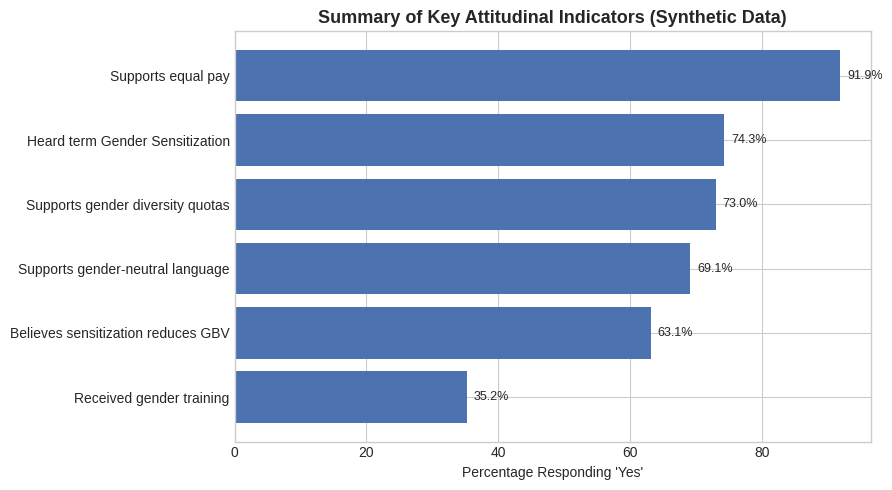

In [13]:
# Build a consolidated summary table of key Yes-response percentages
summary_questions = {
    'Heard term Gender Sensitization': ('heard_term_gender_sensitization', 'Yes'),
    'Received gender training': ('received_gender_training', 'Yes'),
    'Supports equal pay': ('support_equal_pay', 'Yes'),
    'Supports gender diversity quotas': ('support_gender_diversity_quotas', 'Yes'),
    'Supports gender-neutral language': ('support_gender_neutral_language', 'Yes'),
    'Believes sensitization reduces GBV': ('sensitization_reduces_gbv', 'Yes'),
}

summary_rows = []
for label, (col, val) in summary_questions.items():
    pct = (df[col] == val).mean() * 100
    summary_rows.append({'question': label, 'percentage_yes': round(pct, 1)})

final_summary = pd.DataFrame(summary_rows).sort_values('percentage_yes', ascending=False)
display(final_summary)

# --- Matplotlib horizontal bar chart for the summary ---
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(final_summary['question'], final_summary['percentage_yes'], color=PALETTE[0])
ax.set_xlabel("Percentage Responding 'Yes'")
ax.set_title("Summary of Key Attitudinal Indicators (Synthetic Data)")
ax.invert_yaxis()
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.1f}%', xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", va='center', fontsize=9)
plt.tight_layout()
plt.show()


## Summary

In this notebook we applied standard statistical analysis techniques to the synthetic survey dataset:
1. Built frequency tables and percentage breakdowns for key questions.
2. Estimated proportions with 95% confidence intervals.
3. Ran chi-square tests of independence on two variable pairs that had synthetic relationships deliberately built into the data generator, confirming the tests can detect those injected patterns.
4. Computed Cramér's V to quantify effect size/strength of association.
5. Compared stereotype agreement rates across training-status groups.
6. Compiled a consolidated summary table of key indicators.

**Final reminder: this notebook analyzes a synthetic, artificially generated dataset of 1000 fictional respondents. All statistical results — including 'significant' chi-square results — describe patterns intentionally built into the synthetic data generation script, not real-world populations or real survey responses. This notebook should be used only for learning/demonstrating statistical methods, not for drawing real-world conclusions about gender sensitization.**